Successfully loaded imagenet pretrained weights from "/Users/tobias/.cache/torch/checkpoints/osnet_x1_0_imagenet.pth"

0: 384x640 4 PadelBalls, 29.0ms
Speed: 1.0ms preprocess, 29.0ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)


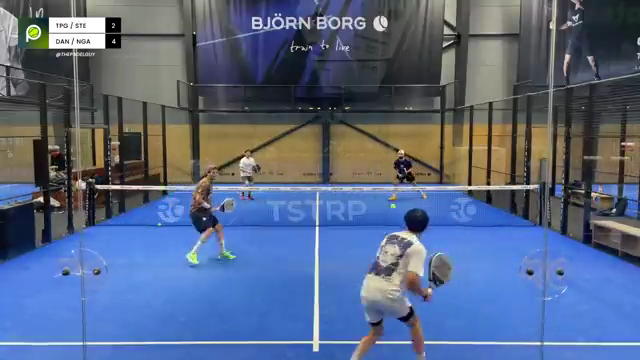

In [8]:
import cv2
import numpy as np
from core.pipeline import PadelTrackingPipeline
import PIL.Image

def display_frame_nb(frame):
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    img = PIL.Image.fromarray(frame_rgb)
    display(img)

pipeline = PadelTrackingPipeline("data/video.mp4")
frame = pipeline.sample_frame()

display_frame_nb(frame)

In [9]:
LEFT_LOWER_NET = [90, 220]
RIGHT_LOWER_NET = [540, 225]
BOTTOM_T_LINE = [315, 340]
TOP_T_LINE = [317, 190]
src_transform_points = [LEFT_LOWER_NET, RIGHT_LOWER_NET, BOTTOM_T_LINE, TOP_T_LINE]

In [10]:
import cv2

def draw_point(frame, x, y, color=(0, 255, 0), thickness=-1, radius=5):
    """
    Draws a point on a given cv2 frame.
    Default color is Green (BGR: 0, 255, 0).
    thickness=-1 fills the circle, making it a solid point.
    """
    # Ensure coordinates are integers
    center_coordinates = (int(x), int(y))
    
    # Draw the circle
    cv2.circle(frame, center_coordinates, radius, color, thickness)
    
    return frame

In [11]:
def get_birdseye_matrix(src_points, flip=True):
    """
    src_points:
        [left_net, right_net, near_T, far_T]
    """

    dst_pts = np.array([
        [0, 10],        # left net
        [10, 10],       # right net
        [5, 3.05],      # near service T
        [5, 16.95]      # far service T
    ], dtype=np.float32)

    if flip:
        court_length = 20.0
        dst_pts[:,1] = court_length - dst_pts[:,1]
        # src_points = src_points[::-1]

    matrix, _ = cv2.findHomography(src_points, dst_pts)
    return matrix

# --- EXAMPLE USAGE ---
# Pixels from your screenshot (approximate for demo)
img_pts = np.array(src_transform_points, dtype=np.float32)

M = get_birdseye_matrix(img_pts)

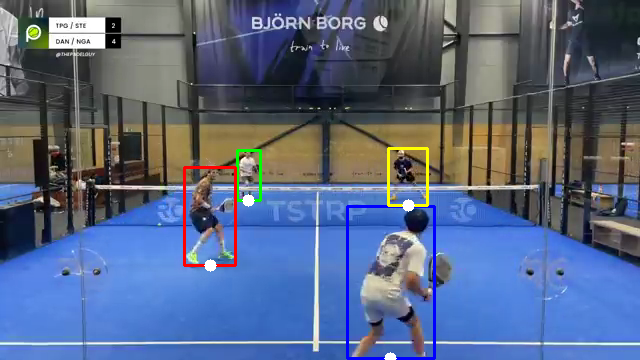

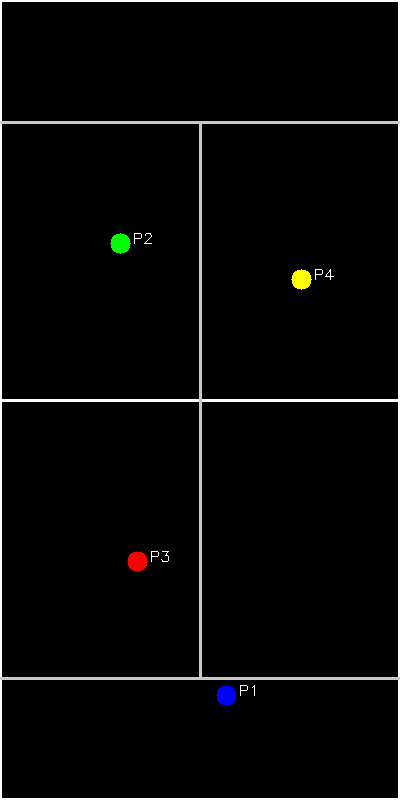

In [12]:
def draw_2d_court(scale=40):
    # --- REAL PADEL DIMENSIONS ---
    court_width_m = 10
    court_length_m = 20

    width = int(court_width_m * scale)
    height = int(court_length_m * scale)

    court = np.zeros((height, width, 3), dtype=np.uint8)

    white = (255, 255, 255)
    gray = (200, 200, 200)

    # Outer boundary
    cv2.rectangle(court, (0, 0), (width-1, height-1), white, 2)

    # Net (10m)
    net_y = int(10 * scale)
    cv2.line(court, (0, net_y), (width, net_y), white, 2)

    # Service lines (3.05m from baselines)
    service_near = int(3.05 * scale)
    service_far = int((20 - 3.05) * scale)

    cv2.line(court, (0, service_near), (width, service_near), gray, 2)
    cv2.line(court, (0, service_far), (width, service_far), gray, 2)

    # Center service line
    center_x = width // 2
    cv2.line(court, (center_x, service_near),
             (center_x, service_far), gray, 2)

    return court

import cv2
import numpy as np

def visualize_mapping(frame, player_coords, matrix):
    """
    player_coords: List of 4 bounding boxes [[x1, y1, x2, y2], ...]
    matrix: The 3x3 Homography matrix calculated earlier
    """
    # 1. Create the 2D canvas (using the previous draw function)
    view_2d = draw_2d_court() 
    scale = 40 # 1 meter = 40 pixels
    
    # Define colors for the 4 players to tell them apart
    colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (0, 255, 255)]
    
    for i, bbox in enumerate(player_coords):
        x1, y1, x2, y2 = bbox
        
        # Calculate the "Foot Point" (Bottom Center of the box)
        feet_x = (x1 + x2) / 2
        feet_y = y2 
        
        # 2. Perspective Transformation
        # We wrap the point in the specific shape OpenCV expects: (1, 1, 2)
        point = np.array([[[feet_x, feet_y]]], dtype=np.float32)
        transformed = cv2.perspectiveTransform(point, matrix)
        m_x, m_y = transformed[0][0] # Real world meters
        
        # 3. Map to 2D Canvas Pixels
        # If your court is 10m wide, draw_x will be between 0 and 400
        draw_x = int(m_x * scale)
        draw_y = int(m_y * scale)
        
        # Boundary Check: Ensure coordinates stay within the drawing canvas
        draw_x = np.clip(draw_x, 0, view_2d.shape[1] - 1)
        draw_y = np.clip(draw_y, 0, view_2d.shape[0] - 1)
        
        # 4. Draw on 2D map
        cv2.circle(view_2d, (draw_x, draw_y), 10, colors[i], -1)
        cv2.putText(view_2d, f"P{i+1}", (draw_x + 12, draw_y), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        
        # 5. Draw on original frame (Visual Verification)
        cv2.rectangle(frame, (int(x1), int(y1)), (int(x2), int(y2)), colors[i], 2)
        cv2.circle(frame, (int(feet_x), int(feet_y)), 6, (255, 255, 255), -1)

    return view_2d

# --- Execution ---
# Example: boxes for 4 players [x1, y1, x2, y2]
player_boxes = [player.latest_xyxy for player in pipeline.identity_manager.players]
top_down_view = visualize_mapping(frame, player_boxes, M)

# Display results side-by-side or separately
display_frame_nb(frame)
display_frame_nb(top_down_view)